In [21]:
dataset = "CIFAR100"

In [22]:
import re
from collections import OrderedDict
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import wandb
PROJECT_PATH = "miller-ml-research/Thesis Runs"
METHOD_ORDER = ["Uniform", "TrainLoss", "RhoLoss", "GradNorm", "DivBS", "Bayesian", "Full"]
HISTORY_KEYS = [
    "epoch",
    "total_step",
    "diagnostics/total_step",
    "train_loss",
    "val_loss",
    "train_acc",
    "val_acc",
    "diagnostics/fixed_train_logits_norm_l2_mean",
    "diagnostics/test_logits_norm_l2_mean",
]
PLOT_SPECS = [
    {"metric": "train_loss", "title": "Train Loss", "y_label": "Loss"},
    {"metric": "val_loss", "title": "Test Loss", "y_label": "Loss"},
    {"metric": "train_acc", "title": "Train Accuracy", "y_label": "Accuracy"},
    {"metric": "val_acc", "title": "Test Accuracy", "y_label": "Accuracy"},
    {"metric": "diagnostics/fixed_train_logits_norm_l2_mean", "title": "Train Normed Logits", "y_label": "L2 Norm"},
    {"metric": "diagnostics/test_logits_norm_l2_mean", "title": "Test Normed Logits", "y_label": "L2 Norm"},
]
CDICT_BSEL = {
    "Uniform": "#66c2a5",
    "RhoLoss": "#fc8d62",
    "DivBS": "#8da0cb",
    "Bayesian": "#e78ac3",
    "geodesic": "#000000",
    "Full": "#717171",
    "GradNorm": "#c76c6c",
    "TrainLoss": "#e1e86e",
}

def _method_palette(methods):
    fallback_colors = sns.color_palette("tab10", n_colors=max(len(methods), 1)).as_hex()
    return {method: CDICT_BSEL.get(method, fallback_colors[index]) for index, method in enumerate(methods)}

sns.set_theme(style="whitegrid", context="talk")
def _normalize_method(method_name):
    if method_name is None:
        return "Unknown"
    method_text = str(method_name).strip()
    canonical_methods = {name.lower(): name for name in METHOD_ORDER}
    lowered = method_text.lower()
    if lowered in canonical_methods:
        return canonical_methods[lowered]
    compact = re.sub(r"[^a-z0-9]", "", lowered)
    aliases = {
        "gradnormis": "GradNorm",
        "gradnorm": "GradNorm",
        "trainloss": "TrainLoss",
        "rholoss": "RhoLoss",
        "uniform": "Uniform",
        "divbs": "DivBS",
        "bayesian": "Bayesian",
        "full": "Full",
    }
    return aliases.get(compact, method_text)
def _extract_dataset_from_name(run_name):
    match = re.match(r"^[^_]+_(.+)_[^_]+_Seed\d+$", run_name or "")
    return match.group(1) if match else None
def _extract_method(run):
    config = dict(getattr(run, "config", {}) or {})
    method_name = config.get("method")
    if method_name:
        return _normalize_method(method_name)
    run_name = getattr(run, "name", "") or ""
    if run_name:
        return _normalize_method(run_name.split("_", 1)[0])
    return "Unknown"
def _extract_dataset(run):
    config = dict(getattr(run, "config", {}) or {})
    dataset_config = config.get("dataset", {})
    if isinstance(dataset_config, dict) and dataset_config.get("name"):
        return str(dataset_config["name"])
    return _extract_dataset_from_name(getattr(run, "name", "") or "")
def _fetch_history(run):
    rows = list(run.scan_history())
    if not rows:
        return None
    history = pd.DataFrame(rows)
    if history.empty:
        return None
    for column in HISTORY_KEYS:
        if column not in history.columns:
            history[column] = pd.NA
    history = history.dropna(subset=["epoch", "total_step", "diagnostics/total_step"], how="all").copy()
    if history.empty:
        return None
    history["epoch"] = pd.to_numeric(history["epoch"], errors="coerce")
    history["total_step"] = pd.to_numeric(history["total_step"], errors="coerce")
    history["diagnostics/total_step"] = pd.to_numeric(history["diagnostics/total_step"], errors="coerce")
    history["total_step"] = history["total_step"].fillna(history["diagnostics/total_step"])
    history = history.dropna(subset=["epoch", "total_step"], how="all").copy()
    if history.empty:
        return None
    if history["epoch"].notna().any():
        history.loc[history["epoch"].notna(), "epoch"] = history.loc[history["epoch"].notna(), "epoch"].astype(int)
    if history["total_step"].notna().any():
        history.loc[history["total_step"].notna(), "total_step"] = history.loc[history["total_step"].notna(), "total_step"].astype(int)
    metric_columns = [spec["metric"] for spec in PLOT_SPECS]
    for column in metric_columns:
        history[column] = pd.to_numeric(history[column], errors="coerce")
    history["run_name"] = run.name
    history["method"] = _extract_method(run)
    history["dataset"] = _extract_dataset(run)
    return history[["dataset", "method", "run_name", "epoch", "total_step", *metric_columns]].copy()
def load_dataset_histories(dataset_name, project_path=PROJECT_PATH):
    api = wandb.Api()
    runs = api.runs(project_path)
    histories = []
    skipped_runs = []
    for run in runs:
        if _extract_dataset(run) != dataset_name:
            continue
        history = _fetch_history(run)
        if history is None:
            skipped_runs.append(run.name)
            continue
        histories.append(history)
    if not histories:
        raise ValueError(f"No W&B histories with the expected metrics were found for dataset={dataset_name!r}.")
    all_history = pd.concat(histories, ignore_index=True)
    all_history = all_history.sort_values(["method", "run_name", "epoch", "total_step"]).reset_index(drop=True)
    run_summary = (
        all_history[["method", "run_name"]]
        .drop_duplicates()
        .groupby("method", observed=True)
        .agg(num_runs=("run_name", "nunique"), runs=("run_name", lambda names: sorted(names)))
        .reset_index()
    )
    if skipped_runs:
        print(f"Skipped {len(skipped_runs)} runs with no usable history.")
    print(f"Loaded {run_summary['num_runs'].sum()} runs for dataset={dataset_name}.")
    display(run_summary)
    return all_history, run_summary
def aggregate_histories(all_history, x_column):
    long_frames = []
    for spec in PLOT_SPECS:
        metric_frame = all_history[["dataset", "method", "run_name", x_column, spec["metric"]]].copy()
        metric_frame = metric_frame.rename(columns={x_column: "x_value", spec["metric"]: "value"})
        metric_frame["metric"] = spec["metric"]
        metric_frame["title"] = spec["title"]
        metric_frame["y_label"] = spec["y_label"]
        long_frames.append(metric_frame)
    long_history = pd.concat(long_frames, ignore_index=True)
    long_history["x_value"] = pd.to_numeric(long_history["x_value"], errors="coerce")
    long_history = long_history.dropna(subset=["x_value", "value"]).copy()
    aggregated = (
        long_history.groupby(["dataset", "method", "metric", "title", "y_label", "x_value"], observed=True)["value"]
        .agg(mean="mean", min="min", max="max")
        .reset_index()
        .sort_values(["metric", "method", "x_value"])
    )
    return long_history, aggregated
def _ordered_methods(aggregated):
    methods = list(OrderedDict.fromkeys(aggregated["method"].tolist()))
    return [method for method in METHOD_ORDER if method in methods] + [method for method in methods if method not in METHOD_ORDER]
def plot_single_metric(aggregated, dataset_name, spec, x_label, log_x=False):
    methods = _ordered_methods(aggregated)
    palette = _method_palette(methods)
    metric_data = aggregated[aggregated["metric"] == spec["metric"]].copy()
    if log_x:
        metric_data = metric_data[metric_data["x_value"] > 0].copy()
    fig, axis = plt.subplots(figsize=(12, 7))
    for method in methods:
        method_data = metric_data[metric_data["method"] == method].sort_values("x_value")
        if method_data.empty:
            continue
        axis.plot(method_data["x_value"], method_data["mean"], label=method, color=palette[method], linewidth=2)
        axis.fill_between(method_data["x_value"].to_numpy(), method_data["min"].to_numpy(), method_data["max"].to_numpy(), color=palette[method], alpha=0.18)
    if log_x:
        axis.set_xscale("log")
    axis.set_title(f"{dataset_name} {spec['title']} by Batch Selection Method ({x_label})")
    axis.set_xlabel(x_label)
    axis.set_ylabel(spec["y_label"])
    axis.grid(True, alpha=0.3)
    axis.legend(frameon=False)
    fig.tight_layout()
    return fig, axis
def plot_all_metrics(epoch_aggregated, step_aggregated, dataset_name):
    generated = []
    for spec in PLOT_SPECS:
        generated.append(plot_single_metric(epoch_aggregated, dataset_name, spec, x_label="Epoch", log_x=False))
        generated.append(plot_single_metric(step_aggregated, dataset_name, spec, x_label="Total Steps", log_x=True))
    return generated


Loaded 35 runs for dataset=CIFAR100.


,method,num_runs,runs
0,Bayesian,5,"[Bayesian_CIFAR100_AdamW_Seed1, Bayesian_CIFAR..."
1,DivBS,5,"[DivBS_CIFAR100_AdamW_Seed1, DivBS_CIFAR100_Ad..."
2,Full,5,"[Full_CIFAR100_AdamW_Seed1, Full_CIFAR100_Adam..."
3,GradNorm,5,"[GradNorm_CIFAR100_AdamW_Seed1, GradNorm_CIFAR..."
4,RhoLoss,5,"[RhoLoss_CIFAR100_AdamW_Seed1, RhoLoss_CIFAR10..."
5,TrainLoss,5,"[TrainLoss_CIFAR100_AdamW_Seed1, TrainLoss_CIF..."
6,Uniform,5,"[Uniform_CIFAR100_AdamW_Seed1, Uniform_CIFAR10..."


,metric,method,epoch_points,step_points
0,diagnostics/fixed_train_logits_norm_l2_mean,Bayesian,53,73
1,diagnostics/fixed_train_logits_norm_l2_mean,DivBS,53,73
2,diagnostics/fixed_train_logits_norm_l2_mean,Full,53,73
3,diagnostics/fixed_train_logits_norm_l2_mean,GradNorm,53,73
4,diagnostics/fixed_train_logits_norm_l2_mean,RhoLoss,53,73
5,diagnostics/fixed_train_logits_norm_l2_mean,TrainLoss,53,73
6,diagnostics/fixed_train_logits_norm_l2_mean,Uniform,53,73
7,diagnostics/test_logits_norm_l2_mean,Bayesian,53,73
8,diagnostics/test_logits_norm_l2_mean,DivBS,53,73
9,diagnostics/test_logits_norm_l2_mean,Full,53,73


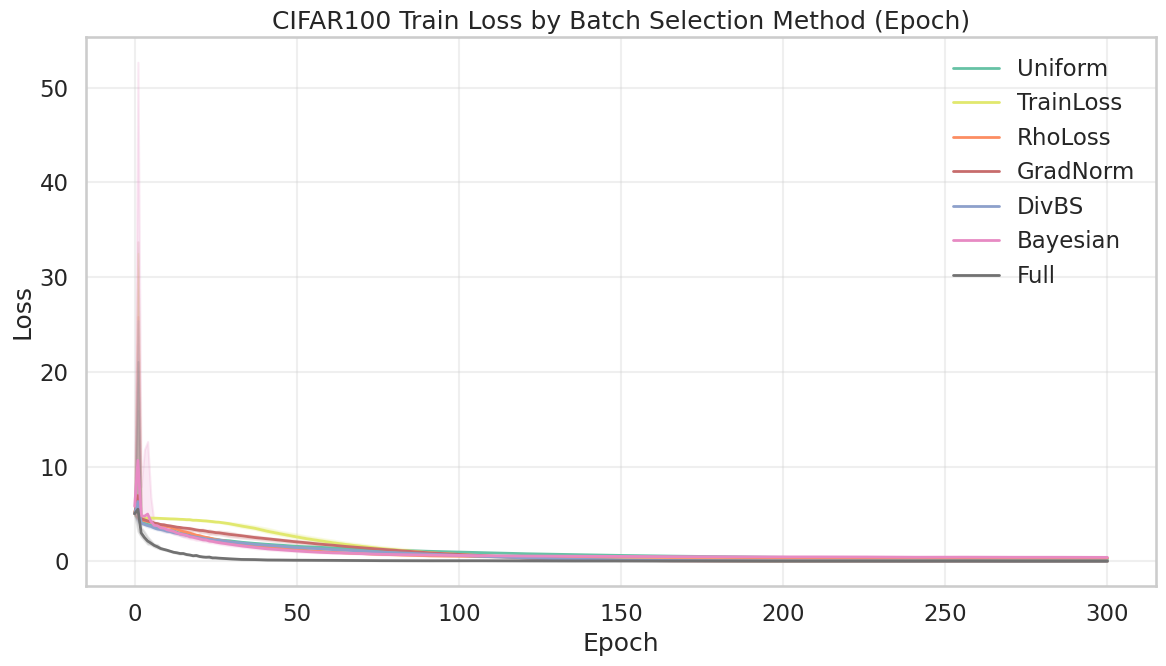

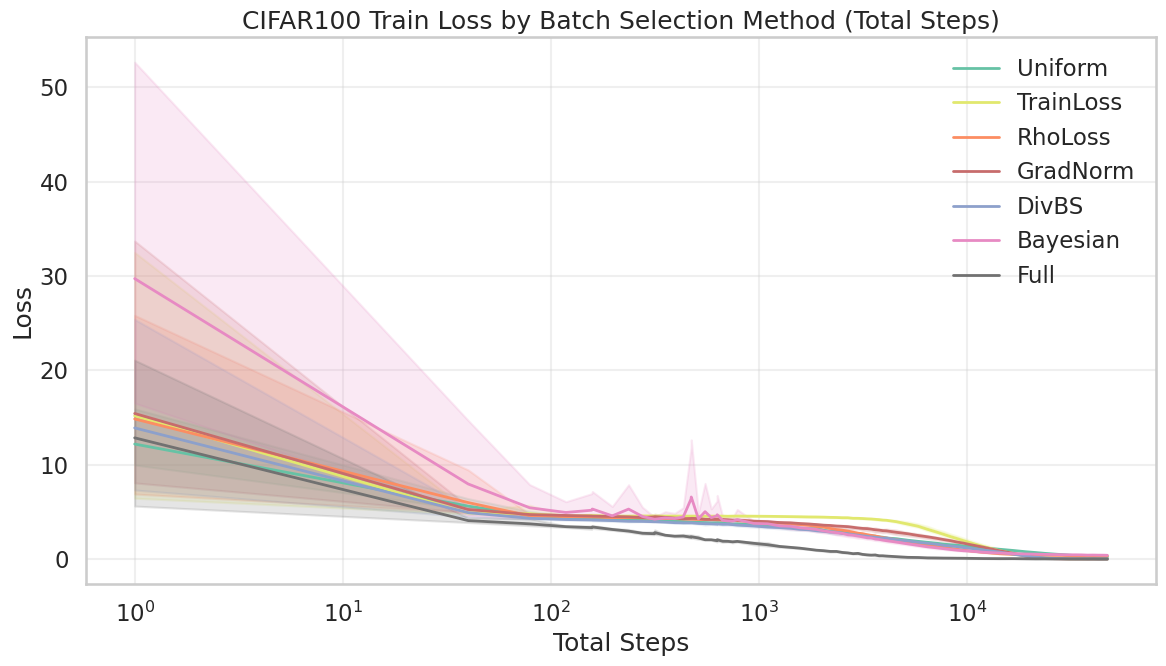

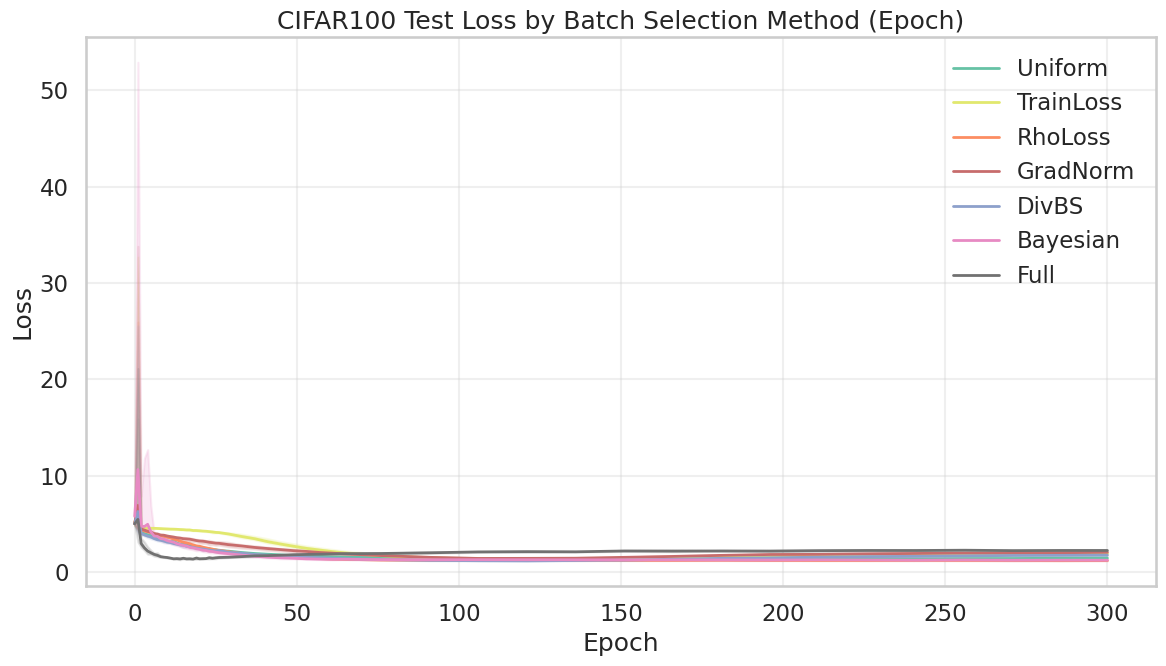

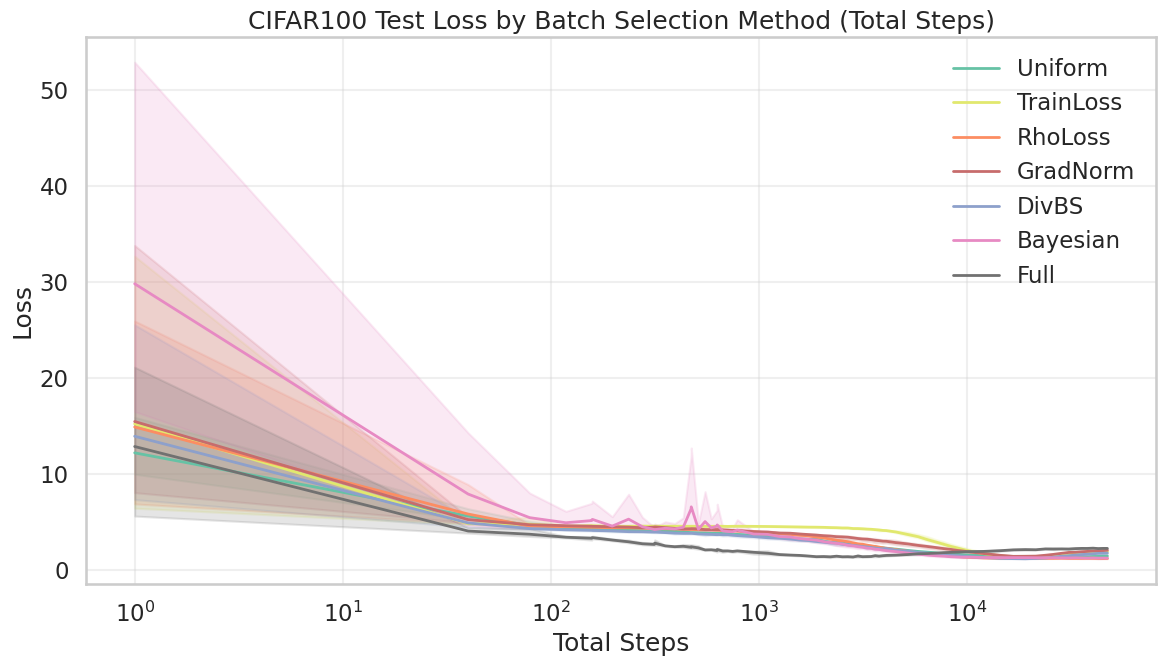

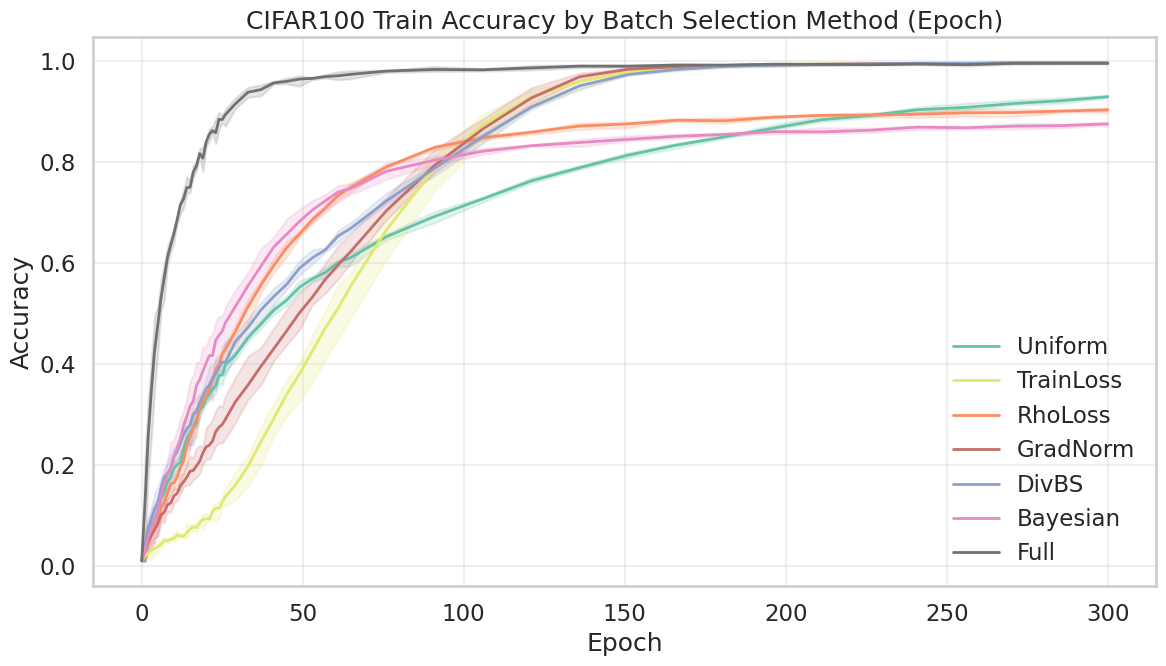

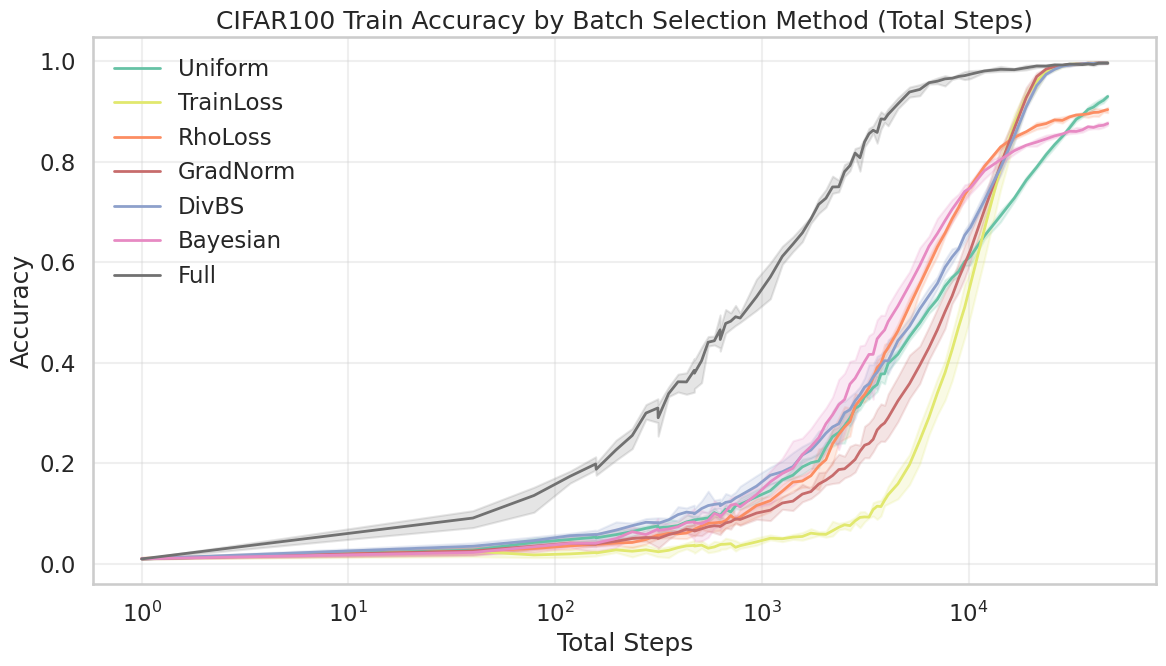

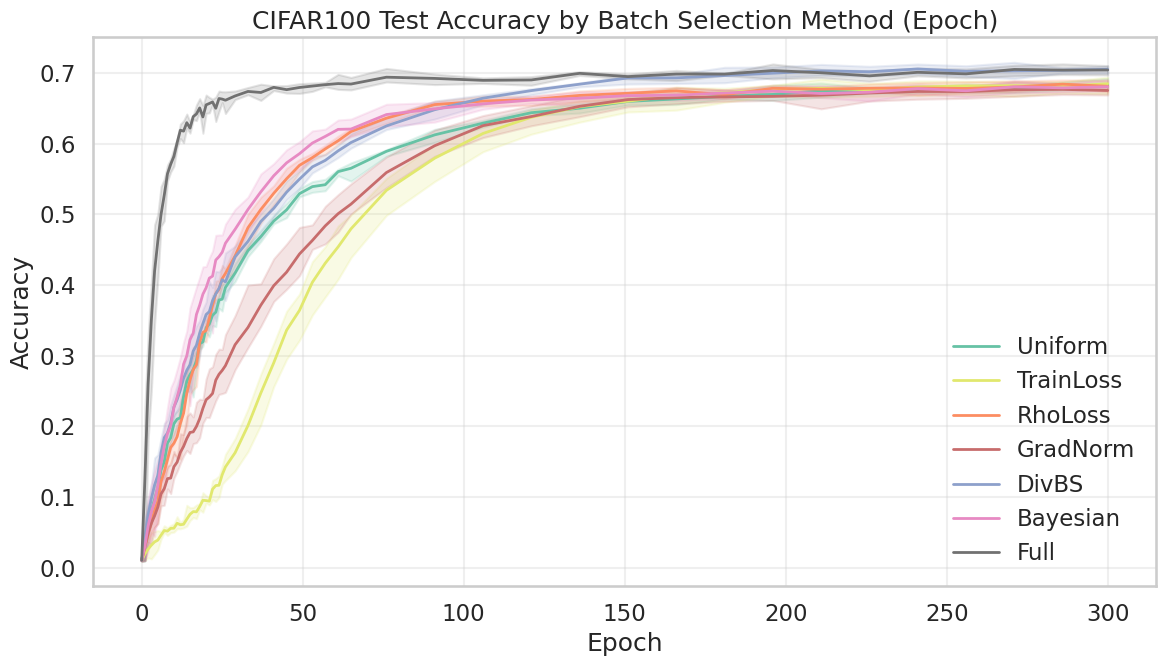

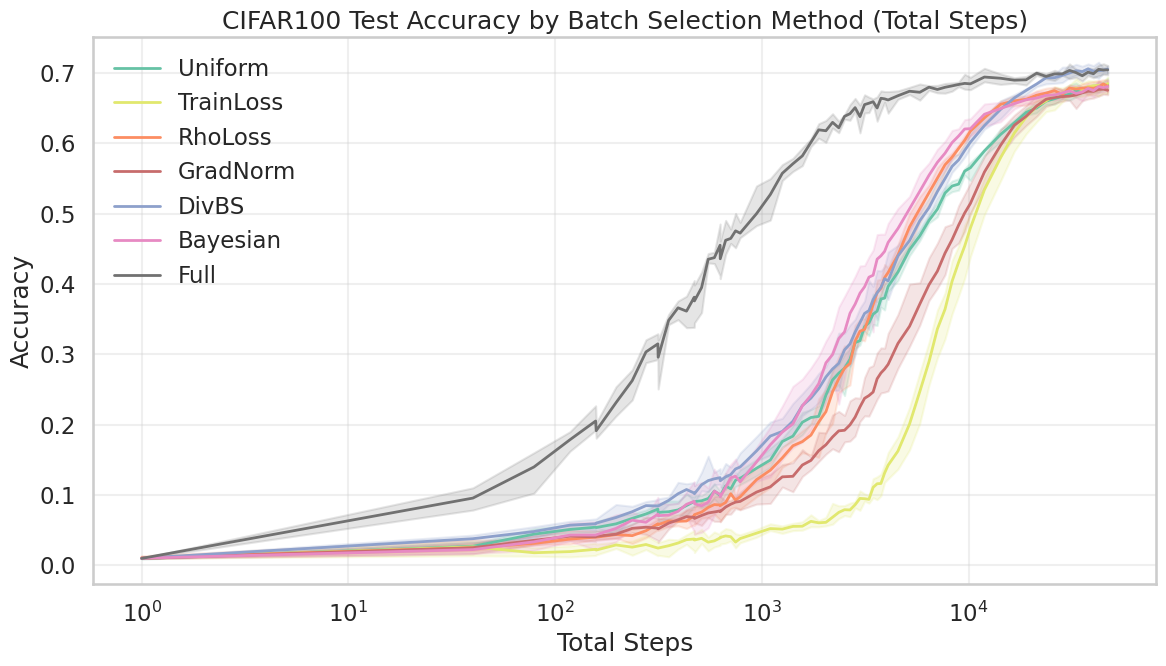

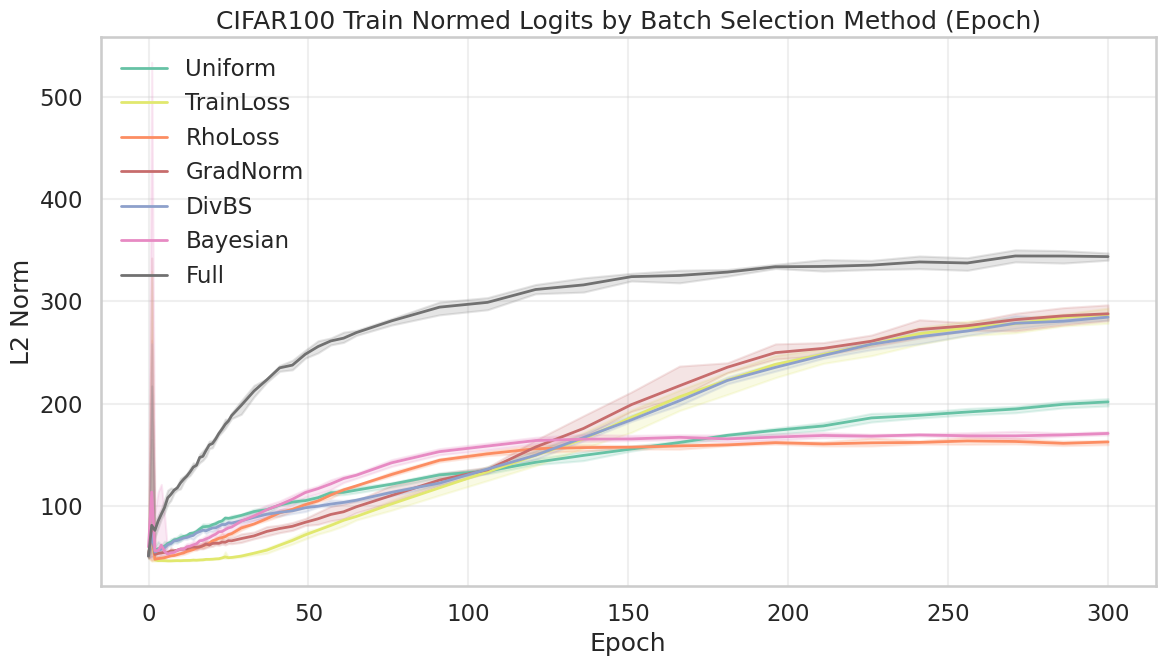

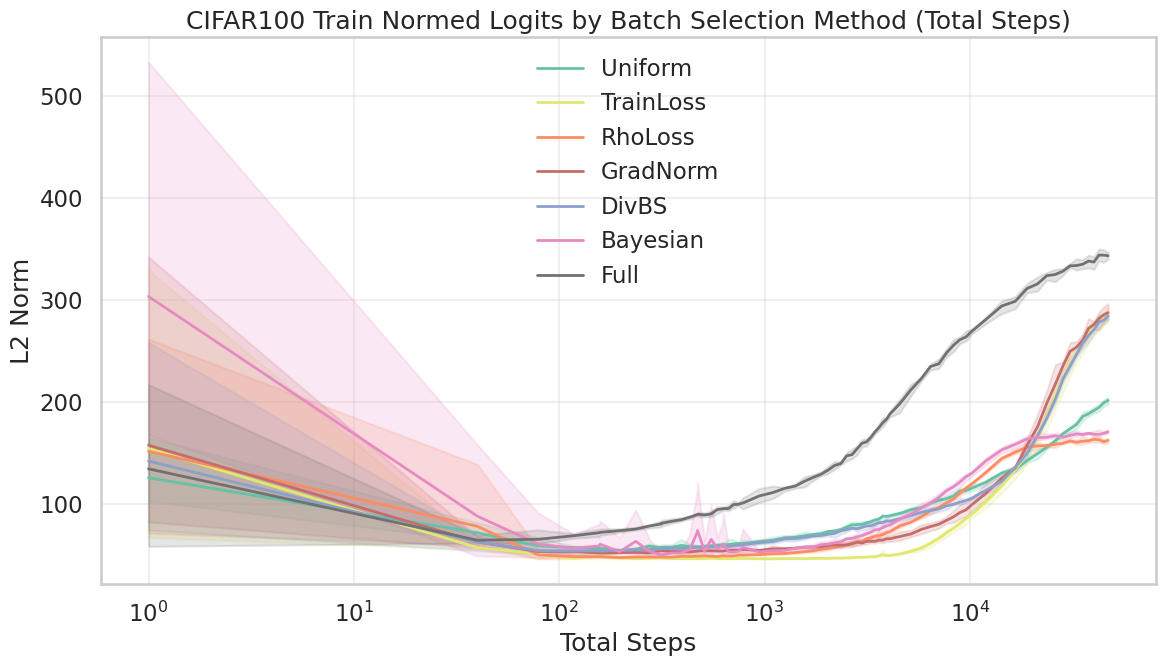

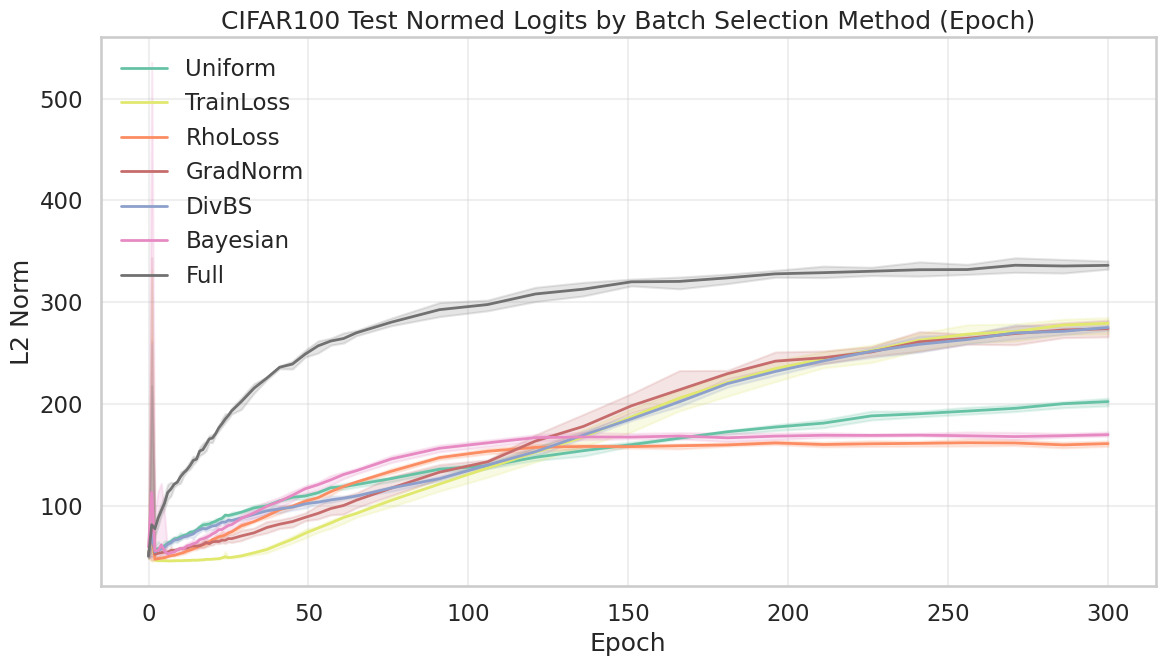

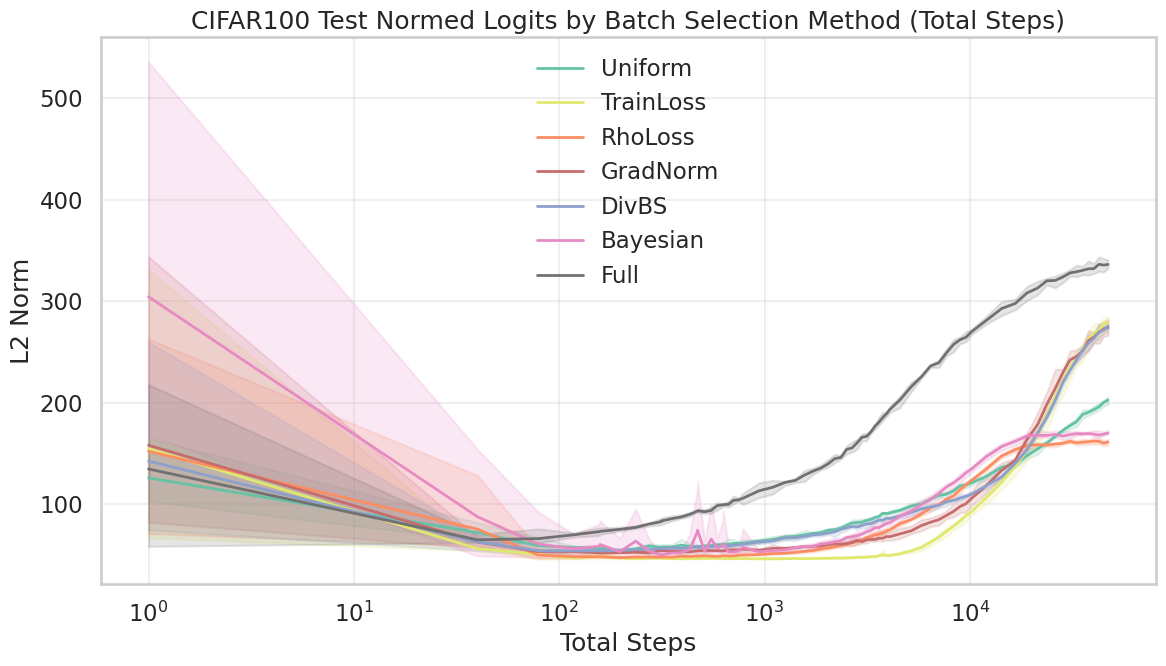

In [23]:
all_history, run_summary = load_dataset_histories(dataset)

epoch_history, epoch_aggregated = aggregate_histories(all_history, "epoch")

step_history, step_aggregated = aggregate_histories(all_history, "total_step")

display(

    pd.concat(

        [

            epoch_aggregated.groupby(["metric", "method"], observed=True).agg(epoch_points=("x_value", "nunique")).reset_index(),

            step_aggregated.groupby(["metric", "method"], observed=True).agg(step_points=("x_value", "nunique")).reset_index().drop(columns=["metric", "method"]),

        ],

        axis=1,

    )

)

generated_plots = plot_all_metrics(epoch_aggregated, step_aggregated, dataset)

plt.show()
